# 🎯 Imitando un algoritmo de trayectoria para el WTAP

**Tarea 4 — Entrenar un modelo de capas densas que imite las decisiones de un algoritmo tradicional**

En este notebook entrenamos una red neuronal que **imita, paso a paso, las decisiones de un algoritmo experto** para construir soluciones del **Weapon-Target Assignment Problem (WTAP)**, un problema de optimización combinatoria **NP-hard**.

Seguimos la misma receta del ejemplo del TSP (*imitation learning*):

1. Un algoritmo **experto** (una *Búsqueda Local Iterada*, un algoritmo de trayectoria) resuelve muchas instancias del WTAP y entrega la **mejor solución conocida** (verificamos que es la óptima con un método exacto).
2. Cada solución se **reproduce paso a paso** como una secuencia de decisiones constructivas: *estando en un estado parcial, ¿a qué objetivo se asigna la próxima arma?*
3. Cada par *(estado parcial → objetivo elegido)* es un ejemplo de entrenamiento.
4. Una **MLP** (capas densas) aprende a predecir el objetivo como un problema de **clasificación multiclase** (un logit por objetivo).

Finalmente usamos el modelo como política de un **agente greedy** (*rollout*) y lo comparamos contra la heurística clásica **MMR** (*Maximum Marginal Return*) y contra el experto.

> ⏱️ El notebook completo corre en CPU en unos 8–15 minutos (la mayor parte es resolver las instancias con el experto y entrenar las 5 configuraciones de la sección 9). No requiere GPU.

### La arquitectura, a grandes rasgos

- **Entrada:** una matriz `T × k` que describe el estado parcial (una fila por objetivo, `k = 15` características).
- **Modelo:** una red MLP de capas densas.
- **Salida:** un puntaje por objetivo → **probabilidad de que la próxima arma se asigne a ese objetivo**.

## 1. Instalación y carga de librerías

Usamos la librería del curso [`eda`](https://github.com/rilianx/eda) para reutilizar exactamente el mismo **agente greedy** del ejemplo del TSP:

- `GreedyAgent`: en cada estado evalúa todas las acciones con una función `eval_actions` y elige la de **mayor puntaje**.
- `SingleAgentSolver`: aplica la política del agente hasta completar la solución (`solve` para una instancia y `multistate_solve` para muchas en paralelo).

El entorno del WTAP (instancia, estado y reglas del juego) lo implementamos nosotros en la sección 2, con la misma interfaz que `TSP_Environment`.

In [1]:
!test -d eda || git clone -q https://github.com/rilianx/eda.git

In [2]:
import os, json, time, copy, random, itertools
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from copy import deepcopy
from torch.utils.data import TensorDataset, DataLoader

from eda.agents import SingleAgentSolver, GreedyAgent
from eda.utils import handle_multiple_states

N_WEAPONS = 10   # W: número fijo de armas
N_TARGETS = 8    # T: número fijo de objetivos (= número de clases de salida de la red)

os.makedirs("figuras", exist_ok=True)
def guardar(fig, nombre):
    fig.savefig(f"figuras/{nombre}.png", dpi=160, bbox_inches="tight")

COLORES = {"Modelo MLP": "tab:blue", "Modelo base (sin anticipación)": "lightsteelblue",
           "MMR (heurística clásica)": "tab:orange", "Greedy secuencial": "tab:gray",
           "Experto (ILS)": "tab:green"}

## 2. El problema: *Weapon-Target Assignment* (WTAP)

Tenemos **W armas** y **T objetivos**. Cada objetivo $j$ tiene un **valor** $V_j$ y cada arma $i$ destruye al objetivo $j$ con **probabilidad** $p_{ij}$ (disparos independientes). Cada arma se asigna a **exactamente un** objetivo ($x_{ij} \in \{0,1\}$, $\sum_j x_{ij} = 1$) y se busca **minimizar el valor esperado que sobrevive**:

$$\min_x \; f(x) = \sum_{j=1}^{T} V_j \prod_{i=1}^{W} (1 - p_{ij})^{x_{ij}}$$

El término $q_j = \prod_i (1-p_{ij})^{x_{ij}}$ es la **probabilidad de que el objetivo $j$ sobreviva**. La función objetivo es **no lineal** y el problema es **NP-hard** (Lloyd & Witsenhausen, 1986): el espacio de soluciones tiene $T^W$ asignaciones ($8^{10} \approx 10^9$ en nuestras instancias).

**Instancias:** siguiendo la literatura (Ahuja et al., 2007) generamos $V_j \sim U\{25,\dots,100\}$ y $p_{ij} \sim U(0.6, 0.9)$, con tamaño fijo **W = 10, T = 8** (una red de capas densas necesita entradas y salidas de tamaño fijo).

### Cómo lo modelamos como algoritmo constructivo (de trayectoria)

- Se parte de la **solución vacía** (ninguna arma asignada) y las armas se asignan **en orden fijo**: arma 0, arma 1, …, arma W−1.
- **Acción constructiva** `("constructive", j)`: asignar la **arma actual** al objetivo `j`. Hay siempre `T` acciones posibles, y el target de la red es directamente el índice `j`.
- Además definimos movimientos de **búsqueda local** sobre soluciones completas (los usa el experto): `("reassign", (i, j))` mueve el arma `i` al objetivo `j`, y `("swap", (i, k))` intercambia los objetivos de dos armas.

In [3]:
class WTAP_Instance:
    def __init__(self, values, probs):
        self.values = np.asarray(values, dtype=float)   # V_j,  forma (T,)
        self.probs  = np.asarray(probs,  dtype=float)   # p_ij, forma (W, T)
        self.n_weapons, self.n_targets = self.probs.shape

    @staticmethod
    def random(n_weapons=N_WEAPONS, n_targets=N_TARGETS, rng=np.random):
        values = rng.randint(25, 101, size=n_targets).astype(float)
        probs  = rng.uniform(0.6, 0.9, size=(n_weapons, n_targets))
        return WTAP_Instance(values, probs)


class WTAP_State:
    # assignment[i] = objetivo asignado al arma i (-1 si aún no se asigna)
    def __init__(self, inst_info, assignment=None):
        self.inst_info = inst_info
        self.assignment = list(assignment) if assignment is not None else [-1] * inst_info.n_weapons
        self.update_cost()

    def update_cost(self):
        # q_j = prob. de que el objetivo j sobreviva; costo = valor esperado que sobrevive
        P = self.inst_info.probs
        self.q = np.ones(self.inst_info.n_targets)
        for i, j in enumerate(self.assignment):
            if j >= 0:
                self.q[j] *= 1 - P[i, j]
        self.cost = float(self.inst_info.values @ self.q)
        return self.cost

    @property
    def current_weapon(self):   # próxima arma a asignar (orden fijo 0, 1, ..., W-1)
        for i, j in enumerate(self.assignment):
            if j < 0:
                return i
        return None

    @property
    def is_complete(self):
        return all(j >= 0 for j in self.assignment)

    def __deepcopy__(self, memo):
        return type(self)(self.inst_info, list(self.assignment))

    def __str__(self):
        return (f"Asignación (arma -> objetivo): {self.assignment}\n"
                f"Valor esperado que sobrevive: {self.cost:.3f}")


class WTAP_Environment:
    @staticmethod
    def gen_actions(state, type, shuffle=False):
        inst = state.inst_info
        if type == "constructive":
            actions = [] if state.is_complete else [("constructive", j) for j in range(inst.n_targets)]
        elif type == "reassign":
            actions = [("reassign", (i, j)) for i in range(inst.n_weapons)
                       for j in range(inst.n_targets) if j != state.assignment[i]]
        elif type == "swap":
            a = state.assignment
            actions = [("swap", (i, k)) for i in range(inst.n_weapons)
                       for k in range(i + 1, inst.n_weapons) if a[i] != a[k]]
        else:
            raise NotImplementedError(f"Tipo de acción '{type}' no implementado")
        if shuffle:
            random.shuffle(actions)
        for action in actions:
            yield action

    @staticmethod
    def state_transition(state, action):
        P, V = state.inst_info.probs, state.inst_info.values
        kind, arg = action
        if kind == "constructive" and not state.is_complete:     # asignar la arma actual al objetivo arg
            i, j = state.current_weapon, arg
            state.assignment[i] = j
            state.q[j] *= 1 - P[i, j]
        elif kind == "reassign" and state.is_complete:            # mover el arma i al objetivo j
            i, j = arg
            a = state.assignment[i]
            state.q[a] /= 1 - P[i, a]
            state.q[j] *= 1 - P[i, j]
            state.assignment[i] = j
        elif kind == "swap" and state.is_complete:                # intercambiar objetivos de i y k
            i, k = arg
            a, b = state.assignment[i], state.assignment[k]
            state.q[a] *= (1 - P[k, a]) / (1 - P[i, a])
            state.q[b] *= (1 - P[i, b]) / (1 - P[k, b])
            state.assignment[i], state.assignment[k] = b, a
        else:
            raise NotImplementedError(f"Movimiento '{action}' no válido para el estado {state}")
        state.cost = float(V @ state.q)
        return state

    @staticmethod
    def calculate_cost_after_action(state, action):
        return WTAP_Environment.state_transition(deepcopy(state), action).cost


def cost_of(inst, assignment):
    # costo de una asignación completa, calculado directamente con la fórmula
    P = inst.probs
    q = np.ones(inst.n_targets)
    for i, j in enumerate(assignment):
        q[j] *= 1 - P[i, j]
    return float(inst.values @ q)

env = WTAP_Environment   # reglas del juego: acciones y transiciones

**Sanity check del entorno:** construimos una solución aleatoria con acciones constructivas y aplicamos movimientos de búsqueda local; en cada paso el costo que se actualiza incrementalmente debe coincidir con el costo calculado desde cero con la fórmula.

In [4]:
random.seed(0)
rng = np.random.RandomState(123)
inst = WTAP_Instance.random(rng=rng)
state = WTAP_State(inst)
print("Costo de la solución vacía (suma de valores):", state.cost)

for _ in range(N_WEAPONS):
    env.state_transition(state, ("constructive", rng.randint(N_TARGETS)))
print(state)

for _ in range(200):
    kind = random.choice(["reassign", "swap"])
    action = random.choice(list(env.gen_actions(state, kind)))
    env.state_transition(state, action)
    assert abs(state.cost - cost_of(inst, state.assignment)) < 1e-9
print("✔ 200 movimientos de búsqueda local: costo incremental == costo recalculado")

Costo de la solución vacía (suma de valores): 563.0
Asignación (arma -> objetivo): [5, 4, 4, 7, 4, 4, 7, 0, 0, 1]
Valor esperado que sobrevive: 263.070
✔ 200 movimientos de búsqueda local: costo incremental == costo recalculado


Visualicemos una instancia: la matriz de probabilidades de destrucción $p_{ij}$ y el valor de cada objetivo. Una buena asignación reparte las armas para que los objetivos **valiosos** reciban armas **efectivas contra ellos**, sin gastar demasiadas armas en un mismo objetivo (rendimientos decrecientes: un segundo disparo solo actúa sobre la probabilidad de supervivencia que quedó).

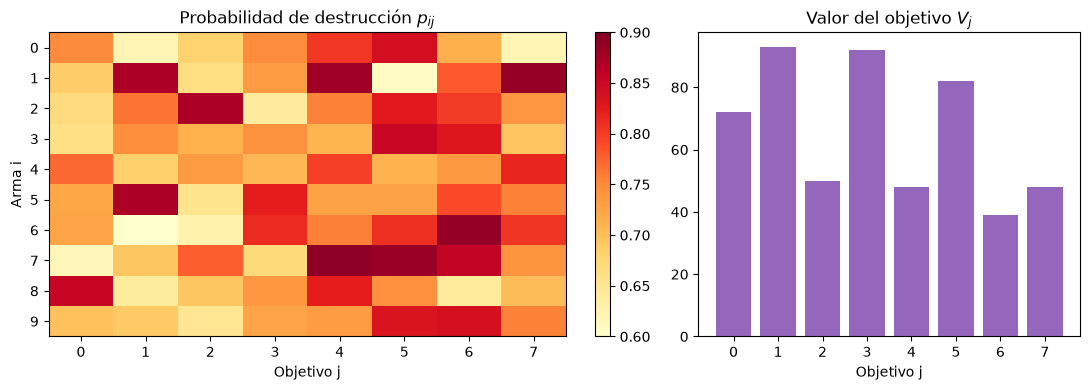

In [5]:
def plot_instance(inst, ax_p=None, ax_v=None):
    if ax_p is None:
        fig, (ax_p, ax_v) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [3, 2]})
    im = ax_p.imshow(inst.probs, cmap="YlOrRd", vmin=0.6, vmax=0.9, aspect="auto")
    ax_p.set_xlabel("Objetivo j"); ax_p.set_ylabel("Arma i")
    ax_p.set_xticks(range(inst.n_targets)); ax_p.set_yticks(range(inst.n_weapons))
    ax_p.set_title("Probabilidad de destrucción $p_{ij}$")
    plt.colorbar(im, ax=ax_p, fraction=0.046)
    ax_v.bar(range(inst.n_targets), inst.values, color="tab:purple")
    ax_v.set_xticks(range(inst.n_targets)); ax_v.set_xlabel("Objetivo j")
    ax_v.set_title("Valor del objetivo $V_j$")
    return ax_p.figure


def plot_assignment(inst, assignment, title="", ax=None):
    # grafo bipartito: armas (izq.) -> objetivos (der.). Tamaño del objetivo ~ valor,
    # color ~ prob. de sobrevivir. Grosor de la línea ~ p_ij de la asignación.
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.2, 5))
    W, T = inst.n_weapons, inst.n_targets
    q = np.ones(T)
    for i, j in enumerate(assignment):
        q[j] *= 1 - inst.probs[i, j]
    yw = np.linspace(1, 0, W); yt = np.linspace(0.95, 0.05, T)
    for i, j in enumerate(assignment):
        ax.plot([0, 1], [yw[i], yt[j]], color="tab:blue", alpha=0.6,
                lw=1 + 6 * (inst.probs[i, j] - 0.6) / 0.3, zorder=1)
    ax.scatter(np.zeros(W), yw, s=160, c="tab:blue", marker="o", zorder=2)
    sc = ax.scatter(np.ones(T), yt, s=inst.values * 6, c=q, cmap="RdYlGn_r", vmin=0, vmax=0.4,
                    marker="s", edgecolors="k", zorder=2)
    for i in range(W): ax.text(-0.08, yw[i], f"a{i}", ha="right", va="center", fontsize=9)
    for j in range(T): ax.text(1.16, yt[j], f"o{j} (V={inst.values[j]:.0f})", ha="left", va="center", fontsize=9)
    cost = float(inst.values @ q)
    ax.set_title(f"{title}\ncosto = {cost:.2f}", fontsize=10)
    ax.set_xlim(-0.35, 1.85); ax.set_ylim(-0.05, 1.05); ax.axis("off")
    return sc

np.random.seed(7)
inst_demo = WTAP_Instance.random()
fig = plot_instance(inst_demo); plt.tight_layout(); guardar(fig, "instancia"); plt.show()

## 3. Heurísticas clásicas (constructivas)

Igual que en el TSP (donde el rival era el *vecino más cercano*), definimos una función de evaluación para el `GreedyAgent`. La más natural es el **greedy secuencial**: la arma actual se asigna al objetivo con **mayor ganancia marginal**, es decir, la mayor reducción del valor esperado:

$$\text{ganancia}_j = V_j \cdot q_j \cdot p_{t j} \qquad (t = \text{arma actual})$$

Pero la heurística clásica del WTAP es **MMR — *Maximum Marginal Return*** (den Broeder et al., 1959): en cada paso elige el **par (arma, objetivo)** de mayor ganancia marginal entre *todas* las armas libres. MMR es más fuerte porque puede decidir qué arma usar primero; el greedy secuencial está obligado a respetar el orden fijo de las armas (igual que nuestro modelo).

In [6]:
@handle_multiple_states
def evalConstructiveActions(state, env):
    # greedy secuencial: ganancia marginal de la arma actual en cada objetivo
    inst, t = state.inst_info, state.current_weapon
    return [(action, inst.values[action[1]] * state.q[action[1]] * inst.probs[t, action[1]])
            for action in env.gen_actions(state, "constructive")]


def mmr(inst):
    # Maximum Marginal Return: elige en cada paso el par (arma libre, objetivo) de mayor ganancia
    V, P = inst.values, inst.probs
    q = np.ones(inst.n_targets)
    assignment = [-1] * inst.n_weapons
    free = list(range(inst.n_weapons))
    while free:
        gains = (V * q)[None, :] * P[free]                 # (armas libres, T)
        r, j = np.unravel_index(np.argmax(gains), gains.shape)
        i = free.pop(r)
        assignment[i] = int(j)
        q[j] *= 1 - P[i, j]
    return assignment


greedy_seq = SingleAgentSolver(env, GreedyAgent(evalConstructiveActions))
sol_seq, *_ = greedy_seq.solve(WTAP_State(inst_demo))
print("Greedy secuencial:\n", sol_seq, "\n")
sol_mmr = WTAP_State(inst_demo, mmr(inst_demo))
print("MMR:\n", sol_mmr)

Greedy secuencial:
 Asignación (arma -> objetivo): [3, 1, 5, 0, 7, 4, 6, 2, 0, 3]
Valor esperado que sobrevive: 73.589 

MMR:
 Asignación (arma -> objetivo): [4, 1, 2, 3, 7, 3, 6, 5, 0, 1]
Valor esperado que sobrevive: 57.081


## 4. El experto: una Búsqueda Local Iterada (algoritmo de trayectoria)

Como experto usamos una metaheurística de trayectoria clásica, la **Búsqueda Local Iterada (ILS)**:

1. **Solución inicial:** la entregada por MMR.
2. **Búsqueda local (best improvement):** evalúa *todos* los movimientos `reassign` y `swap` y aplica el mejor mientras reduzca el costo.
3. **Perturbación:** reasigna aleatoriamente 3 armas y vuelve a aplicar la búsqueda local.
4. **Aceptación:** acepta la nueva solución si mejora (o con probabilidad 5 %, para diversificar) y guarda siempre la **mejor solución encontrada**.

Para que sea rápida, la variación de costo de todos los movimientos se calcula **vectorizada** con `numpy` usando las probabilidades de supervivencia $q_j$:

- `reassign` del arma $i$ (de $a$ a $j$): $\;\Delta = V_a q_a \frac{p_{ia}}{1-p_{ia}} - V_j q_j\, p_{ij}$
- `swap` de las armas $i, k$ (objetivos $a, b$): $\;\Delta = V_a q_a\left(\frac{1-p_{ka}}{1-p_{ia}} - 1\right) + V_b q_b\left(\frac{1-p_{ib}}{1-p_{kb}} - 1\right)$

In [7]:
def q_of(P, a, T):
    q = np.ones(T)
    np.multiply.at(q, a, 1 - P[np.arange(len(a)), a])
    return q


def local_search(V, P, a, q):
    # best improvement con vecindarios reassign + swap (deltas vectorizados)
    W, T = P.shape
    idx = np.arange(W)
    while True:
        pa = P[idx, a]
        removal = V[a] * q[a] * pa / (1 - pa)                   # aumento de costo al quitar el arma i
        delta_re = removal[:, None] - (V * q)[None, :] * P      # (W, T)
        delta_re[idx, a] = np.inf
        term = (V[a] * q[a])[:, None] * ((1 - P[:, a].T) / (1 - pa)[:, None] - 1)
        delta_sw = term + term.T                                # (W, W)
        delta_sw[a[:, None] == a[None, :]] = np.inf
        best_re, best_sw = delta_re.min(), delta_sw.min()
        if min(best_re, best_sw) > -1e-9:                       # óptimo local
            return a, q
        if best_re <= best_sw:
            i, j = np.unravel_index(np.argmin(delta_re), delta_re.shape)
            q[a[i]] /= 1 - P[i, a[i]]; q[j] *= 1 - P[i, j]; a[i] = j
        else:
            i, k = np.unravel_index(np.argmin(delta_sw), delta_sw.shape)
            ai, ak = a[i], a[k]
            q[ai] *= (1 - P[k, ai]) / (1 - P[i, ai])
            q[ak] *= (1 - P[i, ak]) / (1 - P[k, ak])
            a[i], a[k] = ak, ai


def ils(inst, n_iter=100, k_perturb=3, rng=None):
    rng = rng or np.random.default_rng()
    V, P = inst.values, inst.probs
    W, T = P.shape
    a = np.array(mmr(inst))                                      # 1. inicio: MMR
    a, q = local_search(V, P, a, q_of(P, a, T))                  # 2. búsqueda local
    cur_cost = V @ q
    best_a, best_cost = a.copy(), cur_cost
    for _ in range(n_iter):
        b = a.copy()
        ws = rng.choice(W, size=k_perturb, replace=False)        # 3. perturbación
        b[ws] = rng.integers(0, T, size=k_perturb)
        b, qb = local_search(V, P, b, q_of(P, b, T))
        cb = V @ qb
        if cb < cur_cost - 1e-12 or rng.random() < 0.05:         # 4. aceptación
            a, cur_cost = b, cb
        if cb < best_cost - 1e-12:
            best_a, best_cost = b.copy(), cb
    return [int(x) for x in best_a], cost_of(inst, best_a)


t0 = time.time()
sol_ils, cost_ils = ils(inst_demo, rng=np.random.default_rng(0))
print(f"Experto (ILS): {sol_ils}  costo = {cost_ils:.3f}   ({time.time()-t0:.3f} s)")

Experto (ILS): [3, 7, 2, 5, 3, 1, 6, 4, 0, 5]  costo = 52.949   (0.016 s)


### ¿Es realmente la trayectoria óptima?

Las instrucciones piden imitar la **mejor solución conocida**. Para verificar que el ILS encuentra el **óptimo**, lo comparamos con un **método exacto** de *meet-in-the-middle*: dividimos las 10 armas en dos mitades de 5, enumeramos las $8^5 = 32\,768$ asignaciones de cada mitad (con su vector de supervivencia $q^A$, $q^B$) y, como $f = \sum_j V_j\, q^A_j\, q^B_j$, evaluamos las $\approx 10^9$ combinaciones como productos de matrices por bloques. Es exacto pero lento (algunos segundos por instancia), por eso solo lo usamos para validar.

In [8]:
def exact_mitm(inst, chunk=512):
    V, P = inst.values, inst.probs
    W, T = P.shape
    def enum(ws):
        combos = np.array(list(itertools.product(range(T), repeat=len(ws))))
        q = np.ones((len(combos), T))
        for c, w in enumerate(ws):
            np.multiply.at(q, (np.arange(len(combos)), combos[:, c]), 1 - P[w, combos[:, c]])
        return combos, q
    cA, qA = enum(range(W // 2))
    cB, qB = enum(range(W // 2, W))
    qAV, qBt = qA * V, qB.T
    best, bi, bk = np.inf, -1, -1
    for s in range(0, len(qAV), chunk):
        M = qAV[s:s + chunk] @ qBt                   # costos de todas las combinaciones del bloque
        r, c = np.unravel_index(np.argmin(M), M.shape)
        if M[r, c] < best:
            best, bi, bk = M[r, c], s + r, c
    return [int(x) for x in list(cA[bi]) + list(cB[bk])], float(best)


rng = np.random.RandomState(999)
n_check, hits, t_exact = 10, 0, 0
for k in range(n_check):
    inst = WTAP_Instance.random(rng=rng)
    t0 = time.time(); _, c_opt = exact_mitm(inst); t_exact += time.time() - t0
    _, c_ils = ils(inst, rng=np.random.default_rng(k))
    hits += abs(c_ils - c_opt) < 1e-7
    print(f"instancia {k}: óptimo = {c_opt:7.3f} | ILS = {c_ils:7.3f} | MMR = {cost_of(inst, mmr(inst)):7.3f}")
print(f"\nEl ILS encontró el óptimo en {hits}/{n_check} instancias "
      f"(exacto: {t_exact/n_check:.1f} s por instancia)")

instancia 0: óptimo =  42.664 | ILS =  42.664 | MMR =  45.063


instancia 1: óptimo =  29.910 | ILS =  29.910 | MMR =  30.952


instancia 2: óptimo =  42.630 | ILS =  42.630 | MMR =  42.630


instancia 3: óptimo =  45.730 | ILS =  45.730 | MMR =  52.968


instancia 4: óptimo =  46.220 | ILS =  46.220 | MMR =  49.220


instancia 5: óptimo =  41.643 | ILS =  41.643 | MMR =  43.032


instancia 6: óptimo =  56.838 | ILS =  56.838 | MMR =  56.838


instancia 7: óptimo =  37.752 | ILS =  37.752 | MMR =  39.355


instancia 8: óptimo =  55.334 | ILS =  55.334 | MMR =  60.122


instancia 9: óptimo =  39.381 | ILS =  39.381 | MMR =  40.905

El ILS encontró el óptimo en 10/10 instancias (exacto: 2.3 s por instancia)


## 5. Representación del estado (`state2vec`)

Codificamos el estado parcial como una matriz de tamaño fijo `T × 15`, donde **la fila `j` siempre corresponde al objetivo `j`**. Sea $t$ la arma actual (la próxima a asignar):

| # | Característica | Significado |
|---|---|---|
| 0 | `valor` | $V_j / \max V$ |
| 1 | `q_sobrevive` | prob. de que el objetivo sobreviva con las armas ya asignadas |
| 2 | `valor_esperado` | $V_j q_j / \max V$: valor que aún está "en juego" |
| 3 | `p_actual` | $p_{tj}$: efectividad de la arma actual contra $j$ |
| 4 | `ganancia` ⭐ | $V_j q_j p_{tj}$ normalizada por la mayor: **lo que gana la arma actual** (el análogo de `dist_a_actual` del TSP) |
| 5 | `es_mejor_ganancia` | 1 si $j$ es la elección del greedy secuencial |
| 6 | `armas_asignadas` | nº de armas ya asignadas a $j$ / W |
| 7 | `p_futuro_media` | efectividad media de las armas que **faltan** contra $j$ |
| 8 | `ventaja` | $p_{tj}$ − `p_futuro_media`: ¿es la arma actual comparativamente buena para $j$? |
| 9 | `frac_restantes` | fracción de armas que quedan por asignar |
| 10 | `arrepentimiento` ⭐ | ganancia de la arma actual − mejor ganancia de una arma futura en $j$ |
| 11 | `rango` | fracción de armas futuras más efectivas que la actual contra $j$ |
| 12 | `mmr_elige` ⭐ | 1 si, **completando la solución con MMR desde este estado**, la arma actual va a $j$ |
| 13 | `q_final_mmr` | prob. de sobrevivir de $j$ al completar con MMR (anticipación) |
| 14 | `valor_final_mmr` | $V_j\, q^{MMR}_j / \max V$ |

Las características 0–9 describen el estado "actual"; las 10–14 son de **anticipación** (miran a las armas que faltan). Sin ellas la MLP no tiene cómo saber si conviene "guardar" un objetivo para una arma futura más efectiva. En la sección 9 medimos cuánto aportan (ablación).

In [9]:
FEATURES = ["valor", "q_sobrevive", "valor_esperado", "p_actual", "ganancia", "es_mejor_ganancia",
            "armas_asignadas", "p_futuro_media", "ventaja", "frac_restantes",
            "arrepentimiento", "rango", "mmr_elige", "q_final_mmr", "valor_final_mmr"]
VEC_LEN = len(FEATURES)   # k = 15
N_BASE = 10               # las primeras 10 son las características "sin anticipación"


def mmr_completion(V, P, q, t):
    # completa la solución con MMR desde el estado actual (armas t..W-1 libres)
    q = q.copy(); free = list(range(t, P.shape[0])); target_t = -1
    while free:
        gains = (V * q)[None, :] * P[free]
        r, j = np.unravel_index(np.argmax(gains), gains.shape)
        i = free.pop(r); q[j] *= 1 - P[i, j]
        if i == t:
            target_t = j
    return target_t, q


def state2vec(state):
    # Codifica el estado parcial del WTAP como una matriz (T, 15). La fila j es siempre el objetivo j.
    inst = state.inst_info
    V, P = inst.values, inst.probs
    W, T = P.shape
    t, q, vmax = state.current_weapon, state.q, inst.values.max()

    p_cur = P[t]
    gain = V * q * p_cur
    n_asig = np.bincount([j for j in state.assignment if j >= 0], minlength=T)
    rest = P[t + 1:]                                   # armas que faltan después de la actual
    if len(rest):
        p_rest_mean = rest.mean(0)
        regret = (gain - ((V * q)[None, :] * rest).max(0)) / gain.max()
        rank = (rest > p_cur[None, :]).mean(0)
    else:
        p_rest_mean = np.zeros(T); regret = gain / gain.max(); rank = np.zeros(T)
    t_mmr, q_mmr = mmr_completion(V, P, q, t)

    feats = [V / vmax, q, V * q / vmax, p_cur, gain / gain.max(), (gain == gain.max()).astype(float),
             n_asig / W, p_rest_mean, p_cur - p_rest_mean, np.full(T, (W - t) / W),
             regret, rank, (np.arange(T) == t_mmr).astype(float), q_mmr, V * q_mmr / vmax]
    return np.stack(feats, axis=1).astype(np.float32)

Veámoslo en un estado a mitad de camino: tomamos la solución del experto para `inst_demo` y asignamos las primeras 4 armas. Observa que ninguna característica por sí sola "contiene" la respuesta: la red debe aprender a combinarlas.

Armas asignadas: [3, 7, 2, 5]  -> arma actual: 4 | el experto la asigna al objetivo 3

obj |         valor   q_sobrevive      p_actual      ganancia armas_asignad arrepentimien     mmr_elige
---------------------------------------------------------------------------------------------------------
  0 |          0.77          1.00          0.77          0.88          0.00         -0.09          0.00
  1 |          1.00          1.00          0.68          1.00          0.00         -0.28          0.00
  2 |          0.54          0.13          0.74          0.07          0.10         -0.00          0.00
  3 |          0.99          0.25          0.71          0.26          0.10         -0.04          0.00
  4 |          0.52          1.00          0.80          0.60          0.00         -0.07          0.00
  5 |          0.88          0.15          0.71          0.14          0.10         -0.03          1.00
  6 |          0.42          1.00          0.74          0.45          0.00    

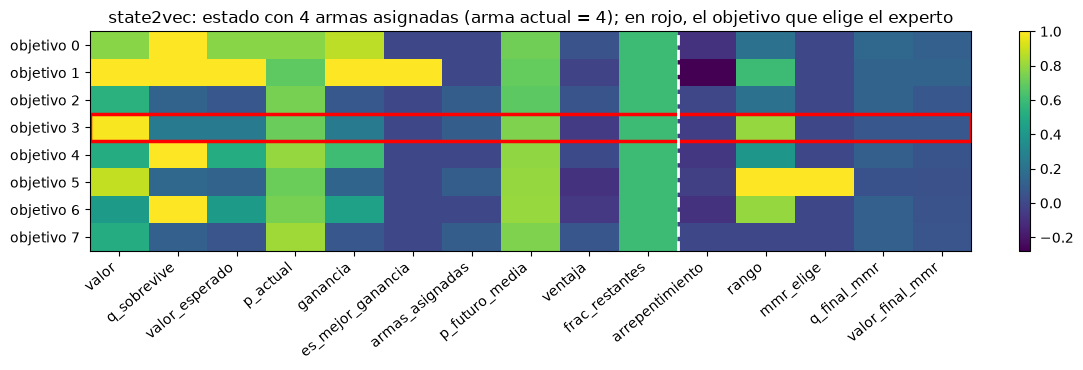

In [10]:
mid_state = WTAP_State(inst_demo)
for t in range(4):
    env.state_transition(mid_state, ("constructive", sol_ils[t]))
vec = state2vec(mid_state)
print(f"Armas asignadas: {mid_state.assignment[:4]}  -> arma actual: {mid_state.current_weapon}"
      f" | el experto la asigna al objetivo {sol_ils[4]}\n")

cols = [0, 1, 3, 4, 6, 10, 12]
print(f"{'obj':>3} | " + " ".join(f"{FEATURES[c][:13]:>13}" for c in cols))
print("-" * 105)
for j, v in enumerate(vec):
    print(f"{j:>3} | " + " ".join(f"{v[c]:>13.2f}" for c in cols))

ej_greedy, ej_mmr, ej_experto = int(np.argmax(vec[:, 4])), int(np.argmax(vec[:, 12])), sol_ils[4]
print(f"\nGreedy (mayor ganancia) elegiría el objetivo {ej_greedy} | completar con MMR: {ej_mmr} "
      f"| el experto elige: {ej_experto}")

fig, ax = plt.subplots(figsize=(11, 3.8))
im = ax.imshow(vec, cmap="viridis", aspect="auto")
ax.set_xticks(range(VEC_LEN)); ax.set_xticklabels(FEATURES, rotation=40, ha="right")
ax.set_yticks(range(N_TARGETS)); ax.set_yticklabels([f"objetivo {j}" for j in range(N_TARGETS)])
ax.axvline(N_BASE - 0.5, color="w", lw=2, ls="--")
ax.add_patch(plt.Rectangle((-0.5, sol_ils[4] - 0.5), VEC_LEN, 1, fill=False, ec="red", lw=2.5))
ax.set_title(f"state2vec: estado con 4 armas asignadas (arma actual = {mid_state.current_weapon}); "
             f"en rojo, el objetivo que elige el experto")
plt.colorbar(im, ax=ax, fraction=0.025); plt.tight_layout(); guardar(fig, "estado"); plt.show()

## 6. Generación de datos de imitación

El plan, igual que en el TSP: resolver muchas instancias con el **experto** y, para cada paso de su solución, guardar el par

- **X:** la matriz `state2vec` del estado parcial,
- **Y:** el índice del objetivo al que el experto asignó la arma actual.

La solución del experto es una asignación completa; la **replicamos paso a paso** con `env.state_transition`, partiendo de la solución vacía y asignando las armas en el orden fijo. Así cada X corresponde exactamente al estado en que se tomó la decisión. Cada instancia genera **W = 10 ejemplos** (todas las decisiones tienen T = 8 opciones).

Resolvemos 6 000 instancias de entrenamiento y 300 de validación (≈1–2 minutos).

In [11]:
def solve_instances(n_instances, seed):
    rng, rng_ils = np.random.RandomState(seed), np.random.default_rng(seed)
    data = []
    for _ in range(n_instances):
        inst = WTAP_Instance.random(rng=rng)
        expert_assignment, expert_cost = ils(inst, rng=rng_ils)
        data.append((inst, expert_assignment, expert_cost))
    return data


def generate_imitation_data(solved):
    X, Y = [], []
    for inst, expert_assignment, _ in solved:
        state = WTAP_State(inst)                        # solución vacía
        for target in expert_assignment:                # arma 0, 1, ..., W-1 (orden fijo)
            X.append(state2vec(state))
            Y.append(target)                            # el target es el objetivo elegido
            env.state_transition(state, ("constructive", target))
    return torch.tensor(np.stack(X)), torch.tensor(Y, dtype=torch.long)


t0 = time.time()
train_solved = solve_instances(6000, seed=0)
val_solved   = solve_instances(300,  seed=1)
print(f"Instancias resueltas por el experto en {time.time()-t0:.0f} s")

X_train, Y_train = generate_imitation_data(train_solved)
X_val,   Y_val   = generate_imitation_data(val_solved)
print("X_train:", tuple(X_train.shape), "-> (muestras, objetivos, características)")
print("Y_train:", tuple(Y_train.shape), "-> objetivo elegido por el experto en cada paso")
print("X_val:  ", tuple(X_val.shape))
print("\nDistribución de clases (objetivo elegido):", np.bincount(Y_train.numpy(), minlength=N_TARGETS))

Instancias resueltas por el experto en 91 s


X_train: (60000, 8, 15) -> (muestras, objetivos, características)
Y_train: (60000,) -> objetivo elegido por el experto en cada paso
X_val:   (3000, 8, 15)

Distribución de clases (objetivo elegido): [7531 7522 7476 7452 7538 7436 7508 7537]


## 7. El modelo en PyTorch

Una MLP que recibe el estado **aplanado** (`T · k = 8 · 15 = 120` valores), lo pasa por capas densas con activación ReLU y **Dropout** (regularización), y produce **un logit por objetivo** (8 salidas). Con `return_probabilities=True` aplica softmax:

$$P(\text{arma actual} \rightarrow \text{objetivo } j) = \text{softmax}(u)_j = \frac{e^{u_j}}{\sum_{l=1}^{T} e^{u_l}}$$

Como un modelo de capas densas no acepta entradas ni salidas de tamaño variable, `T` (y `W`) quedan fijos de antemano.

In [12]:
class WTAP_MLP(nn.Module):
    def __init__(self, n_targets=N_TARGETS, vec_len=VEC_LEN, hidden_sizes=[512, 256, 128], dropout=0.2):
        super().__init__()
        layers = []
        prev = n_targets * vec_len                 # el estado aplanado
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_targets))  # un logit por objetivo
        self.mlp = nn.Sequential(*layers)

    def forward(self, x, return_probabilities=False):
        if x.dim() == 2:                           # un único estado sin dimensión de batch
            x = x.unsqueeze(0)
        logits = self.mlp(x.flatten(1))            # (batch, T*k) -> (batch, T)
        if return_probabilities:
            return torch.softmax(logits, dim=-1)
        return logits


torch.manual_seed(0)
model = WTAP_MLP()
print(model)
print("Parámetros entrenables:", sum(p.numel() for p in model.parameters()))

WTAP_MLP(
  (mlp): Sequential(
    (0): Linear(in_features=120, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=8, bias=True)
  )
)
Parámetros entrenables: 227208


**Sanity check:** con pesos aleatorios la salida tiene forma `(batch, T)` y las probabilidades suman 1 (y son casi uniformes: la red aún no sabe nada).

In [13]:
logits = model(X_train[:4])
probs = model(X_train[:4], return_probabilities=True)
print("Forma de la salida:", tuple(logits.shape), "-> (4 estados, un puntaje por objetivo)")
print("Probabilidades del primer estado:", probs[0].detach().numpy().round(3))
print("Suma de probabilidades por estado:", probs.sum(-1).detach().numpy().round(4))

Forma de la salida: (4, 8) -> (4 estados, un puntaje por objetivo)
Probabilidades del primer estado: [0.121 0.125 0.125 0.126 0.128 0.137 0.11  0.128]
Suma de probabilidades por estado: [1. 1. 1. 1.]


## 8. Entrenamiento

Entrenamos con **entropía cruzada** (`nn.CrossEntropyLoss`) y Adam. El ciclo tiene los mismos 5 pasos por lote del ejemplo del TSP (`zero_grad` → forward → pérdida → `backward` → `step`). Monitoreamos la **pérdida y el accuracy** de entrenamiento y validación en cada época, y aplicamos **early stopping**: si la pérdida de validación no mejora durante `patience` épocas, se detiene y se **restauran los pesos de la mejor época**.

Lo escribimos como función `train_model` para reutilizarlo en los experimentos de la sección 9.

In [14]:
def train_model(X_train, Y_train, X_val, Y_val, hidden_sizes=[512, 256, 128], dropout=0.2,
                batch_size=128, lr=1e-3, num_epochs=200, patience=10, min_delta=1e-3, seed=0, verbose=True):
    torch.manual_seed(seed)
    model = WTAP_MLP(vec_len=X_train.shape[2], hidden_sizes=hidden_sizes, dropout=dropout)
    loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss, best_weights, best_epoch, epochs_no_improve = float("inf"), None, 0, 0

    for epoch in range(num_epochs):
        # ----- fase de entrenamiento -----
        model.train()
        train_loss, train_hits = 0.0, 0
        for xb, yb in loader:
            optimizer.zero_grad()                  # 1. borrar gradientes anteriores
            logits = model(xb)                     # 2. forward
            loss = criterion(logits, yb)           # 3. pérdida
            loss.backward()                        # 4. backward
            optimizer.step()                       # 5. actualizar pesos
            train_loss += loss.item() * xb.size(0)
            train_hits += (logits.argmax(-1) == yb).sum().item()
        train_loss /= len(loader.dataset); train_acc = train_hits / len(loader.dataset)

        # ----- fase de validación -----
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, Y_val).item()
            val_acc = (val_logits.argmax(-1) == Y_val).float().mean().item()

        for key, value in zip(history, [train_loss, val_loss, train_acc, val_acc]):
            history[key].append(value)
        if verbose and epoch % 5 == 0:
            print(f"Época {epoch:3d} | loss train: {train_loss:.3f} | loss val: {val_loss:.3f} "
                  f"| acc train: {train_acc:.3f} | acc val: {val_acc:.3f}")

        # ----- early stopping -----
        if val_loss < best_val_loss - min_delta:
            best_val_loss, best_epoch, epochs_no_improve = val_loss, epoch, 0
            best_weights = copy.deepcopy(model.state_dict())
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"⏹ Early stopping en época {epoch} (sin mejora en {patience} épocas). "
                          f"Mejor época: {best_epoch} | loss val: {best_val_loss:.3f} "
                          f"| acc val: {history['val_acc'][best_epoch]:.3f}")
                break

    model.load_state_dict(best_weights)            # restaurar el mejor modelo
    history["best_epoch"] = best_epoch
    return model, history


t0 = time.time()
model, history = train_model(X_train, Y_train, X_val, Y_val)
print(f"Tiempo de entrenamiento: {time.time()-t0:.0f} s")

Época   0 | loss train: 0.769 | loss val: 0.580 | acc train: 0.769 | acc val: 0.813


Época   5 | loss train: 0.485 | loss val: 0.467 | acc train: 0.829 | acc val: 0.836


Época  10 | loss train: 0.429 | loss val: 0.418 | acc train: 0.846 | acc val: 0.853


Época  15 | loss train: 0.399 | loss val: 0.411 | acc train: 0.854 | acc val: 0.855


Época  20 | loss train: 0.375 | loss val: 0.415 | acc train: 0.860 | acc val: 0.856


⏹ Early stopping en época 23 (sin mejora en 10 épocas). Mejor época: 13 | loss val: 0.410 | acc val: 0.860
Tiempo de entrenamiento: 53 s


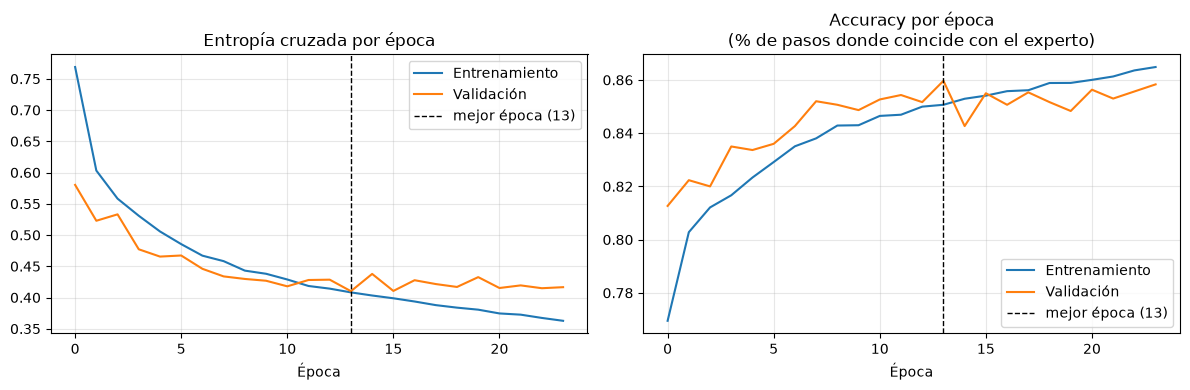

In [15]:
def plot_history(history, title_suffix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = np.arange(len(history["train_loss"])); b = history["best_epoch"]
    axes[0].plot(ep, history["train_loss"], label="Entrenamiento")
    axes[0].plot(ep, history["val_loss"], label="Validación")
    axes[0].set_title("Entropía cruzada por época" + title_suffix); axes[0].set_xlabel("Época")
    axes[1].plot(ep, history["train_acc"], label="Entrenamiento")
    axes[1].plot(ep, history["val_acc"], label="Validación")
    axes[1].set_title("Accuracy por época\n(% de pasos donde coincide con el experto)"); axes[1].set_xlabel("Época")
    for ax in axes:
        ax.axvline(b, color="k", ls="--", lw=1, label=f"mejor época ({b})")
        ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    return fig

fig = plot_history(history); guardar(fig, "curvas"); plt.show()

### Accuracy por paso de la construcción

¿En qué decisiones se equivoca más el modelo? Medimos el accuracy de validación separado por la arma que se está asignando (paso 0 = primera arma).

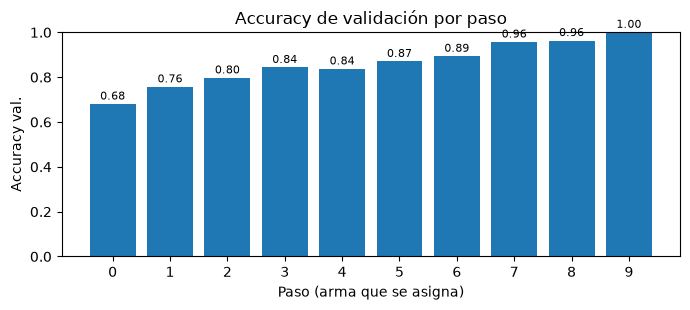

In [16]:
model.eval()
with torch.no_grad():
    pred_val = model(X_val).argmax(-1).numpy()
acc_step = (pred_val == Y_val.numpy()).reshape(-1, N_WEAPONS).mean(0)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(range(N_WEAPONS), acc_step, color="tab:blue")
ax.set_xticks(range(N_WEAPONS)); ax.set_xlabel("Paso (arma que se asigna)"); ax.set_ylabel("Accuracy val.")
ax.set_ylim(0, 1); ax.set_title("Accuracy de validación por paso")
for i, a in enumerate(acc_step): ax.text(i, a + 0.02, f"{a:.2f}", ha="center", fontsize=8)
plt.tight_layout(); guardar(fig, "acc_por_paso"); plt.show()

**Interpretación:** un accuracy de, por ejemplo, 0.85 significa que en el 85 % de los estados el modelo elige **exactamente** el mismo objetivo que el experto. Las primeras decisiones son las más difíciles (quedan muchas armas por asignar y existen varias asignaciones casi equivalentes); las últimas son más fáciles porque el estado ya está muy determinado. En el último paso no quedan armas futuras, así que la decisión óptima es simplemente la de **mayor ganancia marginal** (la característica `es_mejor_ganancia`) y la red la aprende casi perfecto.

## 9. Integración con el agente greedy (rollout) y experimentos

Igual que en el TSP, `GreedyAgent` solo necesita una función que, dado un estado, retorne pares `(acción, puntaje)`. `ModelEvalActions` usa **las probabilidades del modelo como puntajes**: `state2vec` → modelo → `predictions[objetivo]` para cada acción `("constructive", objetivo)`. Soporta listas de estados para resolver muchas instancias en paralelo con `multistate_solve`.

El parámetro `n_features` permite usar modelos entrenados con solo las primeras características (para la ablación).

In [17]:
class ModelEvalActions():
    def __init__(self, model, n_features=VEC_LEN):
        self.model = model
        self.n_features = n_features

    def __call__(self, states, env):
        single_state = not isinstance(states, list)
        if single_state:
            states = [states]
        pending = [k for k, s in enumerate(states) if not s.is_complete]
        evals = [[] for _ in states]
        if pending:
            vecs = np.stack([state2vec(states[k])[:, :self.n_features] for k in pending])
            self.model.eval()
            with torch.no_grad():
                predictions = self.model(torch.tensor(vecs), return_probabilities=True)
            for row, k in enumerate(pending):
                evals[k] = [(action, predictions[row][action[1]].item())   # action[1] = objetivo
                            for action in env.gen_actions(states[k], "constructive")]
        return evals[0] if single_state else evals


def rollout_costs(eval_actions, instances):
    # construye soluciones completas para muchas instancias con el agente greedy
    solver = SingleAgentSolver(env, GreedyAgent(eval_actions))
    final_states, *_ = solver.multistate_solve([WTAP_State(inst) for inst in instances])
    assert all(s.is_complete for s in final_states)
    return np.array([s.cost for s in final_states])


def gap(costs, expert_costs):
    return 100 * (np.asarray(costs) / np.asarray(expert_costs) - 1)

### Experimentos: características e hiperparámetros

> *"Un accuracy alto no garantiza buenos rollouts (¡ni viceversa!): evalúa siempre ambas cosas."*

Comparamos varias configuraciones midiendo **ambas** cosas: el accuracy de validación y el **gap del rollout** en 100 instancias de validación (no en las de test, para no elegir el modelo mirando el test):

- **Ablación de características:** solo las 10 características "actuales" / + comparativas (12) / completas (15).
- **Hiperparámetros:** tamaño de la red, Dropout y tamaño de batch.

In [18]:
val_rollout = val_solved[:100]
val_insts = [inst for inst, _, _ in val_rollout]
val_expert = np.array([c for _, _, c in val_rollout])

configs = [
    # nombre,                               n_feat, hidden,           dropout, batch
    ("A · 10 feats (sin anticipación)",      10,    [512, 256, 128],  0.2,     128),
    ("B · 12 feats (+ comparativas)",        12,    [512, 256, 128],  0.2,     128),
    ("C · 15 feats, [512,256,128], dp 0.2",  15,    [512, 256, 128],  0.2,     128),
    ("D · 15 feats, [256,256], sin dropout", 15,    [256, 256],       0.0,     256),
    ("E · 15 feats, [512,512,256], dp 0.3",  15,    [512, 512, 256],  0.3,     256),
]

experiments = {}
for name, nf, hidden, dp, bs in configs:
    t0 = time.time()
    if name.startswith("C"):          # es la configuración que ya entrenamos en la sección 8
        m, h = model, history
    else:
        m, h = train_model(X_train[:, :, :nf], Y_train, X_val[:, :, :nf], Y_val,
                           hidden_sizes=hidden, dropout=dp, batch_size=bs, verbose=False)
    costs = rollout_costs(ModelEvalActions(m, n_features=nf), val_insts)
    experiments[name] = {"model": m, "history": h, "n_features": nf,
                         "config": {"hidden_sizes": hidden, "dropout": dp, "batch_size": bs},
                         "val_acc": h["val_acc"][h["best_epoch"]],
                         "val_loss": h["val_loss"][h["best_epoch"]],
                         "gap": gap(costs, val_expert).mean()}
    print(f"{name:<40} acc val = {experiments[name]['val_acc']:.3f} | "
          f"gap rollout val = {experiments[name]['gap']:5.2f}% | épocas = {len(h['val_loss'])} "
          f"| {time.time()-t0:.0f} s")

gap_mmr_val = gap([cost_of(i, mmr(i)) for i in val_insts], val_expert).mean()
print(f"\nReferencia en las mismas instancias -> MMR: gap = {gap_mmr_val:.2f}%")

A · 10 feats (sin anticipación)          acc val = 0.767 | gap rollout val = 13.33% | épocas = 28 | 62 s


B · 12 feats (+ comparativas)            acc val = 0.824 | gap rollout val = 10.47% | épocas = 35 | 81 s
C · 15 feats, [512,256,128], dp 0.2      acc val = 0.860 | gap rollout val =  4.20% | épocas = 24 | 0 s


D · 15 feats, [256,256], sin dropout     acc val = 0.856 | gap rollout val =  6.54% | épocas = 34 | 26 s


E · 15 feats, [512,512,256], dp 0.3      acc val = 0.858 | gap rollout val =  3.97% | épocas = 38 | 92 s

Referencia en las mismas instancias -> MMR: gap = 6.94%


Modelo elegido (menor gap en validación): E · 15 feats, [512,512,256], dp 0.3


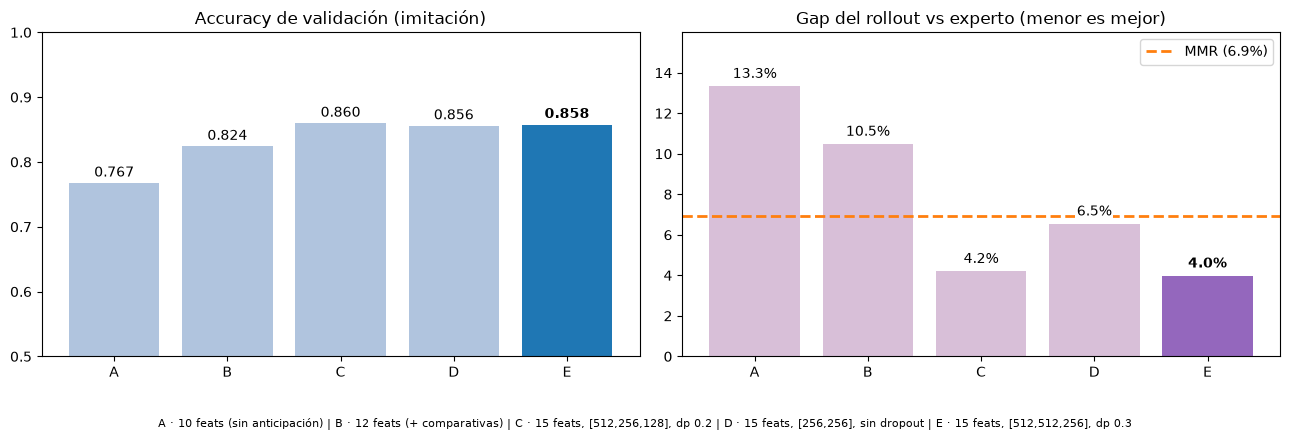

In [19]:
best_name = min(experiments, key=lambda n: experiments[n]["gap"])
best = experiments[best_name]
print("Modelo elegido (menor gap en validación):", best_name)

names = list(experiments)
accs = [experiments[n]["val_acc"] for n in names]
gaps_exp = [experiments[n]["gap"] for n in names]
short = [n.split(" · ")[0] for n in names]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(short, accs, color=["tab:blue" if n == best_name else "lightsteelblue" for n in names])
axes[0].set_ylim(0.5, 1); axes[0].set_title("Accuracy de validación (imitación)")
axes[1].bar(short, gaps_exp, color=["tab:purple" if n == best_name else "thistle" for n in names])
axes[1].axhline(gap_mmr_val, color="tab:orange", ls="--", lw=2, label=f"MMR ({gap_mmr_val:.1f}%)")
axes[1].set_title("Gap del rollout vs experto (menor es mejor)"); axes[1].legend(loc="upper right")
axes[1].set_ylim(0, max(gaps_exp) * 1.2)
for ax, vals, fmt, off in [(axes[0], accs, "{:.3f}", 0.005), (axes[1], gaps_exp, "{:.1f}%", 0.25)]:
    for i, v in enumerate(vals):
        ax.text(i, v + off, fmt.format(v), ha="center", va="bottom", fontsize=10,
                fontweight="bold" if names[i] == best_name else "normal",
                bbox=dict(facecolor="white", edgecolor="none", pad=1))
fig.text(0.5, -0.08, " | ".join(names), ha="center", fontsize=8)
plt.tight_layout(); guardar(fig, "experimentos"); plt.show()

La ablación muestra el efecto de las características **relativas al paso** y de **anticipación**: con solo las 10 características "actuales" la red imita peor y sus rollouts quedan lejos del experto; al agregar las comparativas y la anticipación MMR sube el accuracy y, sobre todo, baja el gap.

A partir de aquí usamos el modelo con **menor gap en validación**.

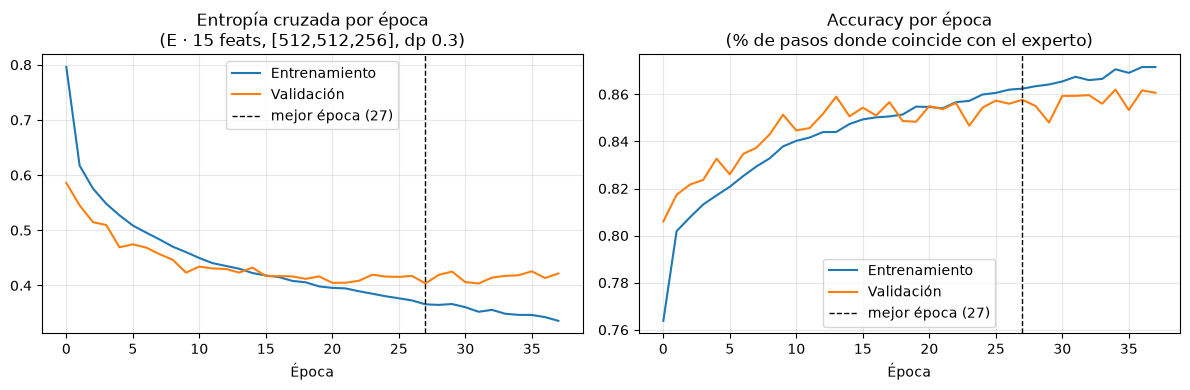

In [20]:
if best_name != "C · 15 feats, [512,256,128], dp 0.2":
    fig = plot_history(best["history"], f"\n({best_name})"); guardar(fig, "curvas_mejor"); plt.show()

### Rollout: los competidores sobre una misma instancia nueva

- **Modelo MLP** (agente greedy guiado por la red),
- **Greedy secuencial** (mismo orden de armas, ganancia marginal),
- **MMR** (heurística clásica del WTAP),
- **Experto (ILS)**.

Modelo MLP:         [0, 7, 4, 2, 0, 1, 3, 6, 5, 4] costo = 45.525
Greedy secuencial:  [0, 6, 4, 5, 1, 3, 7, 2, 6, 0] costo = 59.994
MMR:                [0, 0, 4, 7, 2, 1, 3, 6, 5, 4] costo = 47.233
Experto (ILS):      [0, 0, 4, 2, 7, 1, 3, 6, 5, 4] costo = 44.284


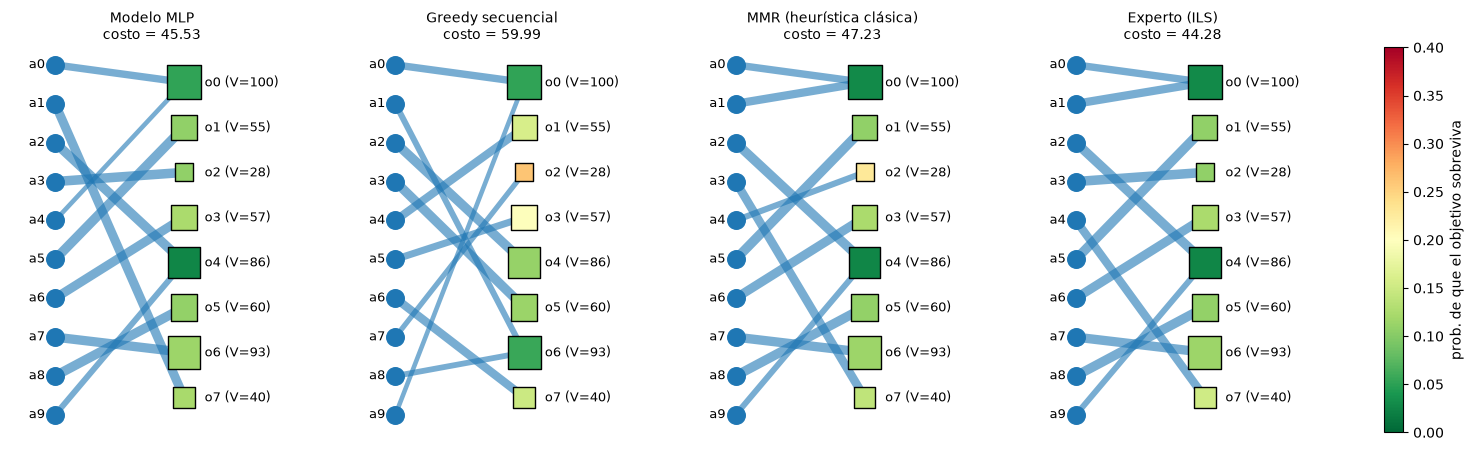

In [21]:
final_model, final_nf = best["model"], best["n_features"]
np.random.seed(45)
test_inst = WTAP_Instance.random()

agent_model = SingleAgentSolver(env, GreedyAgent(ModelEvalActions(final_model, final_nf)))
sol_model, *_ = agent_model.solve(WTAP_State(test_inst))
sol_seq, *_ = SingleAgentSolver(env, GreedyAgent(evalConstructiveActions)).solve(WTAP_State(test_inst))
a_mmr = mmr(test_inst)
a_exp, c_exp = ils(test_inst, rng=np.random.default_rng(45))

print("Modelo MLP:        ", sol_model.assignment, f"costo = {sol_model.cost:.3f}")
print("Greedy secuencial: ", sol_seq.assignment, f"costo = {sol_seq.cost:.3f}")
print("MMR:               ", a_mmr, f"costo = {cost_of(test_inst, a_mmr):.3f}")
print("Experto (ILS):     ", a_exp, f"costo = {c_exp:.3f}")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (name, a) in zip(axes, [("Modelo MLP", sol_model.assignment), ("Greedy secuencial", sol_seq.assignment),
                                ("MMR (heurística clásica)", a_mmr), ("Experto (ILS)", a_exp)]):
    sc = plot_assignment(test_inst, a, name, ax=ax)
fig.colorbar(sc, ax=axes, fraction=0.015, label="prob. de que el objetivo sobreviva")
guardar(fig, "rollout_ejemplo"); plt.show()

## 10. Evaluación sistemática en 50 instancias nuevas

Evaluamos todos los métodos sobre **50 instancias nuevas** (semilla distinta a entrenamiento y validación) y reportamos el costo medio y el **gap promedio** respecto al experto:

$$\text{gap} = \left(\frac{\text{costo del método}}{\text{costo del experto}} - 1\right) \times 100\%$$

Incluimos también el modelo base (sin anticipación) para ver el efecto de las características en instancias nunca vistas.

In [22]:
test_solved = solve_instances(50, seed=2024)
test_insts = [inst for inst, _, _ in test_solved]
expert_costs = np.array([c for _, _, c in test_solved])

base = experiments["A · 10 feats (sin anticipación)"]
results = {
    "Modelo MLP": rollout_costs(ModelEvalActions(final_model, final_nf), test_insts),
    "Modelo base (sin anticipación)": rollout_costs(ModelEvalActions(base["model"], base["n_features"]), test_insts),
    "MMR (heurística clásica)": np.array([cost_of(i, mmr(i)) for i in test_insts]),
    "Greedy secuencial": rollout_costs(evalConstructiveActions, test_insts),
    "Experto (ILS)": expert_costs,
}

print(f"{'Método':<32} {'Costo medio':>11} {'Gap promedio':>13} {'Gap mediana':>12} {'% óptimo':>9}")
print("-" * 82)
for name, costs in results.items():
    g = gap(costs, expert_costs)
    print(f"{name:<32} {costs.mean():>11.2f} {g.mean():>12.2f}% {np.median(g):>11.2f}% "
          f"{100*np.mean(g < 1e-6):>8.0f}%")

wins = np.mean(results["Modelo MLP"] < results["MMR (heurística clásica)"] - 1e-9)
ties = np.mean(np.abs(results["Modelo MLP"] - results["MMR (heurística clásica)"]) <= 1e-9)
print(f"\nModelo MLP vs MMR: mejor en {100*wins:.0f}% de las instancias, igual en {100*ties:.0f}%, "
      f"peor en {100*(1-wins-ties):.0f}%")

Método                           Costo medio  Gap promedio  Gap mediana  % óptimo
----------------------------------------------------------------------------------
Modelo MLP                             48.26         4.42%        3.74%       20%
Modelo base (sin anticipación)         50.94         9.95%        8.30%        6%
MMR (heurística clásica)               49.83         7.68%        7.75%        6%
Greedy secuencial                      68.44        49.29%       48.64%        0%
Experto (ILS)                          46.26         0.00%        0.00%      100%

Modelo MLP vs MMR: mejor en 60% de las instancias, igual en 14%, peor en 26%


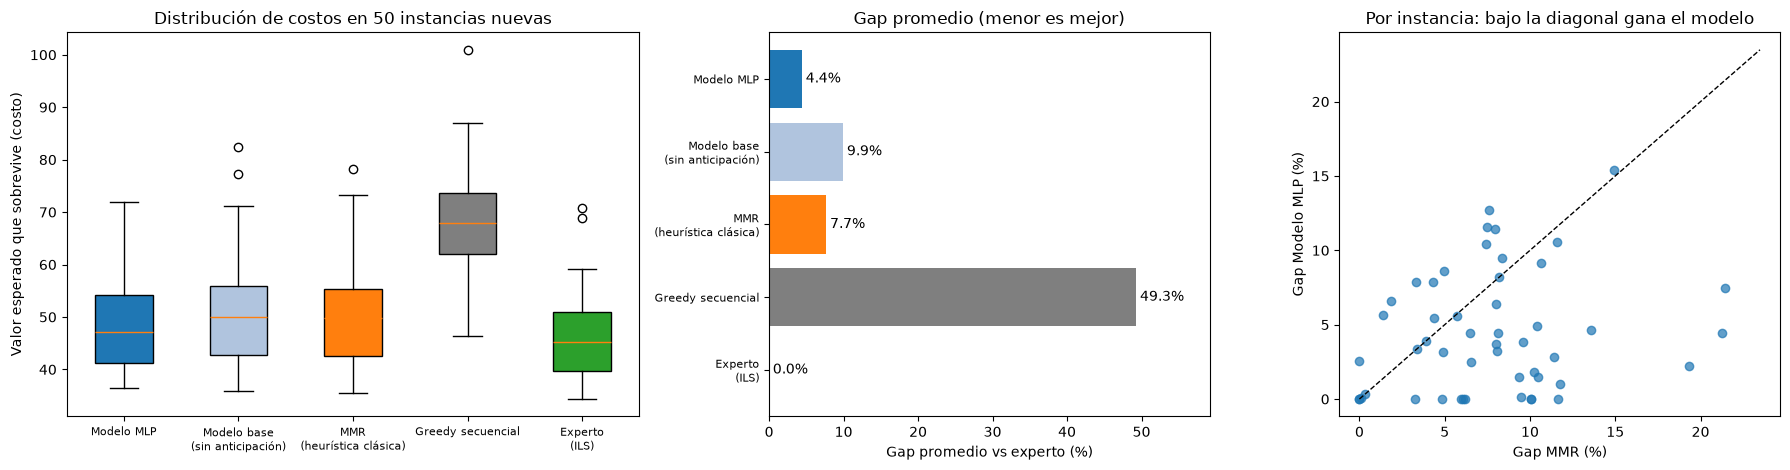

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), gridspec_kw={"width_ratios": [1.3, 1, 1]})
names = list(results)
labels = [n.replace(" (", "\n(") for n in names]
bp = axes[0].boxplot([results[n] for n in names], tick_labels=labels, patch_artist=True)
for patch, n in zip(bp["boxes"], names): patch.set_facecolor(COLORES[n])
axes[0].set_ylabel("Valor esperado que sobrevive (costo)")
axes[0].set_title("Distribución de costos en 50 instancias nuevas"); axes[0].tick_params(axis="x", labelsize=8)

gaps_mean = [gap(results[n], expert_costs).mean() for n in names]
axes[1].barh(labels[::-1], gaps_mean[::-1], color=[COLORES[n] for n in names][::-1])
for i, v in enumerate(gaps_mean[::-1]): axes[1].text(v + 0.5, i, f"{v:.1f}%", va="center")
axes[1].set_xlabel("Gap promedio vs experto (%)"); axes[1].set_title("Gap promedio (menor es mejor)")
axes[1].tick_params(axis="y", labelsize=8); axes[1].set_xlim(0, max(gaps_mean) * 1.2)

g_model = gap(results["Modelo MLP"], expert_costs); g_mmr = gap(results["MMR (heurística clásica)"], expert_costs)
lim = max(g_model.max(), g_mmr.max()) * 1.05 + 1
axes[2].scatter(g_mmr, g_model, color="tab:blue", alpha=0.7)
axes[2].plot([0, lim], [0, lim], "k--", lw=1)
axes[2].set_xlabel("Gap MMR (%)"); axes[2].set_ylabel("Gap Modelo MLP (%)")
axes[2].set_title("Por instancia: bajo la diagonal gana el modelo")
plt.tight_layout(); guardar(fig, "comparacion"); plt.show()

In [24]:
# resumen numérico (se usa para la presentación)
summary = {
    "n_train_instances": len(train_solved), "n_train_samples": int(len(Y_train)),
    "n_val_samples": int(len(Y_val)), "n_test_instances": len(test_insts),
    "final_model": best_name, "final_n_features": int(final_nf), "final_config": best["config"],
    "val_acc_final": float(best["val_acc"]), "best_epoch_final": int(best["history"]["best_epoch"]),
    "epochs_final": len(best["history"]["val_loss"]),
    "val_acc_base": float(base["val_acc"]),
    "ils_optimal_hits": int(hits), "ils_optimal_checked": int(n_check),
    "experiments": {n: {"val_acc": float(e["val_acc"]), "gap_val": float(e["gap"])} for n, e in experiments.items()},
    "gap_mmr_val": float(gap_mmr_val),
    "test": {n: {"mean_cost": float(c.mean()), "mean_gap": float(gap(c, expert_costs).mean()),
                 "pct_optimal": float(100 * np.mean(gap(c, expert_costs) < 1e-6))} for n, c in results.items()},
    "model_vs_mmr": {"wins": float(wins), "ties": float(ties)},
    "ejemplo_estado": {"greedy": ej_greedy, "mmr": ej_mmr, "experto": ej_experto},
}
with open("figuras/resultados.json", "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(json.dumps(summary["test"], indent=2, ensure_ascii=False))

{
  "Modelo MLP": {
    "mean_cost": 48.257214942859044,
    "mean_gap": 4.415030131335313,
    "pct_optimal": 20.0
  },
  "Modelo base (sin anticipación)": {
    "mean_cost": 50.940917926303094,
    "mean_gap": 9.947213135628786,
    "pct_optimal": 6.0
  },
  "MMR (heurística clásica)": {
    "mean_cost": 49.83016348193226,
    "mean_gap": 7.682223203939117,
    "pct_optimal": 6.0
  },
  "Greedy secuencial": {
    "mean_cost": 68.44047853789715,
    "mean_gap": 49.29060534785315,
    "pct_optimal": 0.0
  },
  "Experto (ILS)": {
    "mean_cost": 46.26281573773545,
    "mean_gap": 0.0,
    "pct_optimal": 100.0
  }
}


## 11. Discusión

### ¿Qué aprendió el modelo?

- La MLP imita al experto en la mayoría de las decisiones (≈86 % de accuracy en nuestra ejecución) y, usada dentro del **mismo agente greedy** que el greedy secuencial (misma restricción de orden de armas), construye soluciones **mucho mejores** que él: aprendió a no gastar la arma actual en el objetivo de mayor ganancia inmediata cuando una arma futura es comparativamente mejor para ese objetivo.
- En instancias nuevas el modelo final **supera en promedio a la heurística clásica MMR** y gana o empata en la mayoría de las instancias, a pesar de que MMR puede elegir libremente qué arma asignar y el modelo no.
- La **ablación** muestra que las características **relativas al paso** y de **anticipación** son las que realmente informan la decisión (como `dist_a_actual` en el TSP): sin ellas (configuración A) el modelo imita peor y en el rollout queda por detrás de MMR.
- **Accuracy vs rollout:** las configuraciones C, D y E tienen prácticamente el mismo accuracy (≈0,86), pero en nuestra ejecución D (sin Dropout) tuvo un gap de rollout claramente mayor. Un error temprano lleva al agente a estados que el experto nunca visitó (*distribution shift*) y los errores se acumulan; por eso elegimos el modelo por el **gap** y no por el accuracy.

### Limitaciones

- **Tamaño fijo:** la MLP solo sirve para instancias con exactamente W = 10 armas y T = 8 objetivos; otro tamaño exige reentrenar.
- **Pesos por posición:** al aplanar la entrada, el objetivo $j$ y el logit $j$ están conectados con pesos distintos a los del objetivo $l$, aunque la pregunta ("¿qué tan buen objetivo es para la arma actual?") es la misma. Arquitecturas que comparten pesos entre elementos (por ejemplo *pointer networks* o *transformers*) evitarían esto.
- **Orden fijo de armas:** el agente no puede elegir qué arma asignar primero (MMR sí puede).

### Extensiones posibles

- **DAgger:** volver a etiquetar con el experto los estados que visita el propio modelo, para reducir el *distribution shift*.
- **Aumento de datos:** permutar el orden de armas/objetivos de cada instancia resuelta (la solución óptima se permuta igual).
- **Modelo + búsqueda local:** usar la solución del modelo como punto de partida de la búsqueda local `reassign`/`swap`.